<a href="https://colab.research.google.com/github/HojuneLee0106/04/blob/main/04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

가상 데이터 셋을 생성한 뒤 학습, 검증, 테스트 데이터 셋으로 분할해 보세요.

In [7]:
import pandas as pd
import numpy as np
import random
data={
    "feature1": np.random.randint(0, 100, size=100),
    "feature2": np.random.randint(0, 100, size=100),
    "labgel":[1 if x%2==0 else 0 for x in range(1,101)]
}
df=pd.DataFrame(data)
print(df)

    feature1  feature2  labgel
0          5        12       0
1         78        69       1
2         87        40       0
3         32        68       1
4         49        35       0
..       ...       ...     ...
95        16        68       1
96         1         0       0
97         6        42       1
98         6        27       0
99        33        42       1

[100 rows x 3 columns]


In [10]:
from sklearn.model_selection import train_test_split
train_data, test_data=train_test_split(df, test_size=0.2, random_state=42)
print(train_data)
print(test_data)

    feature1  feature2  labgel
55        75        43       1
88        78        59       0
26        85        68       0
42        14        21       0
69        71        43       1
..       ...       ...     ...
60        19        23       0
71         6        28       1
14        23        75       0
92        64        73       0
51        18        99       1

[80 rows x 3 columns]
    feature1  feature2  labgel
83        59        56       1
53         4        51       1
70        86        39       0
45        52        29       1
44        19        37       0
39        23        16       1
22         6         4       0
80        91        63       0
10        56        95       0
0          5        12       0
18        31         0       0
30        67        25       0
73        64        86       1
33        97        14       1
90         8        94       0
4         49        35       0
76        80        30       0
77        25        55       1
12        92    

가상 데이터 셋을 생성하고 KNN을 이용하여 학습 예측 수행해보시오

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [16]:
#사분면 맞추기 데이터 셋
import numpy as np
import random
x=np.random.randint(-100,100,size=100)
y=np.random.randint(-100,100,size=100)
def where(x,y):
  if x>0 and y>0:
    return 1
  elif x<0 and y>0:
    return 2
  elif x<0 and y<0:
    return 3
  elif x>0 and y<0:
    return 4
  else:
    return 0
data={
    "x":x,
    "y":y,
    "label":[where(x[i],y[i]) for i in range(100)]
}
df=pd.DataFrame(data)
print(df)

     x   y  label
0  -88  40      2
1  -22 -77      3
2  -95  14      2
3   83  93      1
4   62  38      1
..  ..  ..    ...
95 -94 -83      3
96 -79  99      2
97  75 -60      4
98 -81  62      2
99 -22 -89      3

[100 rows x 3 columns]


In [18]:
X=df[["x","y"]].values
y=df["label"].values
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
X_train_tensor=torch.tensor(X_train, dtype=torch.float32)
y_train_tensor=torch.tensor(y_train, dtype=torch.long)
X_test_tensor=torch.tensor(X_test,dtype=torch.float32)
y_test_tensor=torch.tensor(y_test, dtype=torch.long)

In [19]:
k=5
knn_model=KNeighborsClassifier(n_neighbors=k)
knn_model.fit(X_train_tensor.numpy(), y_train_tensor.numpy())

KNeighborsClassifier()

In [20]:
accuracy=knn_model.score(X_test_tensor.numpy(), y_test_tensor.numpy())
print(f"정확도 :{accuracy}")

정확도 :0.9


In [23]:
sample=X_test_tensor[0].reshape(1,-1).numpy()
prediction=knn_model.predict(sample)
print(sample)
print(prediction)

[[ 0.750813   -0.51583767]]
[4]


동일한 이진 분류 가상 데이터셋을 생성하고, Perceptron, SVM, Random Forest, Naive Bayes 네 가지 알고리즘으로 학습해 보세요.


In [30]:
from sklearn.datasets import make_classification
import pandas as pd
X,y=make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.5,
    random_state=42
)
df=pd.DataFrame(X,columns=["f1","f2"])
df["label"]=y
print(df)

           f1        f2  label
0    1.101034  2.035353      1
1    1.255945 -1.672352      0
2    1.854479 -1.448528      0
3    3.603090 -0.266515      0
4    1.253178  1.287514      1
..        ...       ...    ...
995  2.213939  0.951639      1
996  2.009473 -1.294996      0
997  3.344315  0.711294      1
998  0.474124  2.119258      1
999  4.141478  0.256925      0

[1000 rows x 3 columns]


퍼셉트론

In [32]:
weights=np.random.rand(2)
bias=np.random.rand(1)
learing_rate=0.1
epochs=50
def step_function(x):
  return 1 if x>=0 else 0
for epoch in range(epochs):
  for i in range(len(X)):
    total_input=np.dot(X[i],weights)+bias
    prediction=step_function(total_input)
    error=y[i]-prediction
    weights+=learing_rate*error*X[i]
    bias+=learing_rate*error

In [39]:
def predict(input_data):
  total_input=np.dot(input_data, weights)+bias
  return step_function(total_input)

In [40]:
correct = 0
for i in range(len(X)):
    if predict(X[i]) == y[i]:
        correct += 1

accuracy = correct / len(X) * 100
print(f"테스트 데이터 정확도: {accuracy:.2f}%")

정확도: 91.40%


SVM

In [42]:
from sklearn.svm import SVC
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
X_train_tensor=torch.tensor(X_train, dtype=torch.float32)
y_train_tensor=torch.tensor(y_train, dtype=torch.long)
X_test_tensor=torch.tensor(X_test, dtype=torch.float32)
y_test_tensor=torch.tensor(y_test, dtype=torch.long)
svm_model=SVC(kernel="linear")
svm_model.fit(X_train_tensor.numpy(), y_train_tensor.numpy())
accuracy=svm_model.score(X_test_tensor.numpy(), y_test_tensor.numpy())
print(f"테스트 데이터 정확도: {accuracy:.2f}")

테스트 데이터 정확도: 0.97


RandomForest

In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
print("random Forest 모델 학습 중")
rf_model=RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

random Forest 모델 학습 중


RandomForestClassifier(max_depth=10, n_estimators=50, random_state=42)

In [44]:
accuracy=rf_model.score(X_test, y_test)
print(f"테스트 데이터 정확도: {accuracy:.2f}")

테스트 데이터 정확도: 0.99


Naive Bayes

In [46]:
from sklearn.naive_bayes import GaussianNB
nb_model=GaussianNB()
nb_model.fit(X_train_tensor.numpy(), y_train_tensor.numpy())

GaussianNB()

In [47]:
accuracy = nb_model.score(X_test_tensor.numpy(), y_test_tensor.numpy())
print(f"테스트 데이터 정확도: {accuracy:.2f}")

테스트 데이터 정확도: 0.97


가상 데이터셋을 준비하고, 증강(Data Augmentation) 기법을 적용했을 때와 적용하지 않았을 때 모델 성능을 비교하세요.

In [49]:
X, y=make_classification(
    n_samples=1000,
    n_features=4,
    n_informative=4,
    n_redundant=0,
    weights=[0.9, 0.1],
    random_state=42
)
#노이즈 추가
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)
noise=np.random.normal(0, 0.1, X_train.shape)
X_aug=np.vstack([X_train, X_train+noise])
y_aug=np.hstack([y_train, y_train])
model_1=RandomForestClassifier(n_estimators=50, random_state=42)
model_2=RandomForestClassifier(n_estimators=50, random_state=42)
model_1.fit(X_train, y_train)
model_2.fit(X_aug, y_aug)
score_model_1=model_1.score(X_test,y_test)
score_model_2=model_2.score(X_test,y_test)
print(f"모델 1 성능: {score_model_1}")
print(f"모델 2 성능: {score_model_2}")

모델 1 성능: 0.93
모델 2 성능: 0.94


활성화 함수를 직접 정의하고, 활성화 함수를 적용한 출력을 계산하고, 결과를 그래프로 시각화하세요.

In [54]:
def sigmoid(x):
  return 1/(1+np.exp(-x))
def tanh(x):
  return np.tanh(x)
def relu(x):
  return np.maximum(0,x)
#직접 해보기 Leacky Relu
def LeakyRelu(x):
  return x if x>=0 else 0.1*x

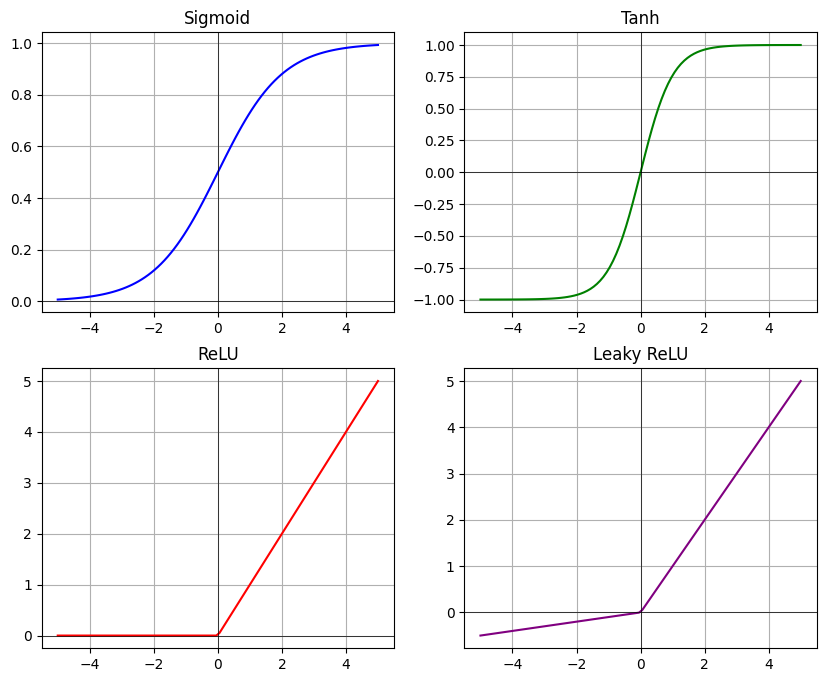

In [57]:
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 100)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

#Sigmoid
axes[0, 0].plot(x, sigmoid(x), color="blue")
axes[0, 0].set_title("Sigmoid")
axes[0, 0].axhline(0, color="black", linewidth=0.5)  # x축
axes[0, 0].axvline(0, color="black", linewidth=0.5)  # y축
axes[0, 0].grid(True)

# Tanh
axes[0, 1].plot(x, tanh(x), color="green")
axes[0, 1].set_title("Tanh")
axes[0, 1].axhline(0, color="black", linewidth=0.5)
axes[0, 1].axvline(0, color="black", linewidth=0.5)
axes[0, 1].grid(True)

# ReLU
axes[1, 0].plot(x, relu(x), color="red")
axes[1, 0].set_title("ReLU")
axes[1, 0].axhline(0, color="black", linewidth=0.5)
axes[1, 0].axvline(0, color="black", linewidth=0.5)
axes[1, 0].grid(True)

# Leaky ReLU
axes[1, 1].plot(x, [LeakyRelu(i) for i in x], color="purple")
axes[1, 1].set_title("Leaky ReLU")
axes[1, 1].axhline(0, color="black", linewidth=0.5)
axes[1, 1].axvline(0, color="black", linewidth=0.5)
axes[1, 1].grid(True)

plt.show()

비선형 데이터셋을 생성하고, MLP(다층 퍼셉트론) 모델을 설계하고 학습시켜 분류를 수행하세요.

In [58]:
#비선형 데이터 셋 생성
from sklearn.datasets import make_moons
X,y=make_moons(n_samples=1000, noise=0.2, random_state=42)

In [69]:
import torch.nn as nn
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
class MLP(nn.Module):
  def __init__(self):
    super(MLP, self).__init__()
    self.layers=nn.Sequential(
        nn.Linear(2,64),
        nn.ReLU(),
        nn.Linear(64,32),
        nn.ReLU(),
        nn.Linear(32,2)
    )
  def forward(self, x):
    return self.layers(x)
X_train_t=torch.tensor(X_train, dtype=torch.float32)
y_train_t=torch.tensor(y_train,dtype=torch.long)
X_test_t=torch.tensor(X_test, dtype=torch.float32)
y_test_t=torch.tensor(y_test, dtype=torch.long)
model=MLP()
optimizer=torch.optim.Adam(model.parameters(), lr=0.01)
criterion=nn.CrossEntropyLoss()
for epoch in range(50):
  optimizer.zero_grad()
  output=model(X_train_t)
  loss=criterion(output, y_train_t)
  loss.backward()
  optimizer.step()
with torch.no_grad():
  preds=model(X_test_t).argmax(dim=1)
  accuracy=(preds==y_test_t).float().mean()
  print(f"정확도: {accuracy:.2f}")

정확도: 0.99


CNN(Convolutional Neural Network)을 직접 구성하여 이미지 분류를 수행하세요.

In [77]:
import tensorflow as tf

# MNIST
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
X_train=X_train/255.0
X_test=X_test/255.0
X_train_t=torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
X_test_t=torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_train_t=torch.tensor(y_train, dtype=torch.long)
y_test_t=torch.tensor(y_test, dtype=torch.long)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=64, shuffle=False)

In [78]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
class SimpleCNN(nn.Module):
  def __init__(self, num_classes):
    super(SimpleCNN, self).__init__()
    self.conv1 = nn.Conv2d(1,32,kernel_size=3,padding=1)
    self.pool=nn.MaxPool2d(kernel_size=2,stride=2)
    self.conv2=nn.Conv2d(32,64,kernel_size=3,padding=1)
    self.conv3=nn.Conv2d(64,128,kernel_size=3,padding=1)
    self.flatten=nn.Flatten()
    self.fc1=nn.Linear(128*3*3,256)
    self.fc2=nn.Linear(256,num_classes)
  def forward(self,x):
    x=torch.relu(self.conv1(x))
    x=self.pool(x)
    x=torch.relu(self.conv2(x))
    x=self.pool(x)
    x=torch.relu(self.conv3(x))
    x=self.pool(x)
    x=self.flatten(x)
    x=torch.relu(self.fc1(x))
    x=self.fc2(x)
    return x
model=SimpleCNN(num_classes=10)


In [80]:
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(), lr=0.001)
num_epochs=10
for epoch in range(num_epochs):
  model.train()
  running_loss=0.0
  for inputs, labels in train_loader:
    optimizer.zero_grad()
    outputs=model(inputs)
    loss=criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss+=loss.item()
  print(f'Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}')

Epoch 1, Loss: 0.1619138366734879
Epoch 2, Loss: 0.044649097185618165
Epoch 3, Loss: 0.030961730910721037
Epoch 4, Loss: 0.024390809778766984
Epoch 5, Loss: 0.020263674075085135
Epoch 6, Loss: 0.014127968108617025
Epoch 7, Loss: 0.013453281158867606
Epoch 8, Loss: 0.011092467764660262
Epoch 9, Loss: 0.010083669237491136
Epoch 10, Loss: 0.008191607760039021


In [84]:
model.eval()
correct=0
total=0
with torch.no_grad():
  for inputs, labels in test_loader:
    outputs=model(inputs)
    _, predicted=torch.max(outputs,1)
    total+=labels.size(0)
    correct+=(predicted==labels).sum().item()
accuracy=correct/total
print(f'Test Accuracy: {accuracy * 100:.2f}%')

Test Accuracy: 99.04%
